# Feature Description and Matching
## Scale-invariant Feature Transform (SIFT)

Import the packages and load the image `Book.jpg`

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

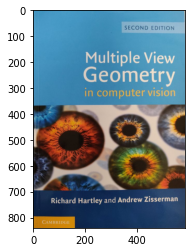

In [3]:
path = "C:/Users/peisz/OneDrive/Documents/Egyetem/DTU/3rd semester/PAS/Week 2/"
img = cv2.imread(path + "Book.jpg")

b,g,r = cv2.split(img) # Changing the order from bgr to rgb so that matplotlib can show it
img = cv2.merge([r,g,b])
plt.imshow(img)

We'll start by converting the image to grayscale.

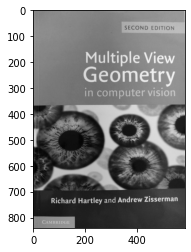

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.imshow(gray, cmap = 'gray')

Now we will attempt to find the features and descriptors using [SIFT](https://docs.opencv.org/4.7.0/d7/d60/classcv_1_1SIFT.html). In OpenCV we will do it by first creating a SIFT object using `cv2.SIFT_create`, and then use the class method `detectAndCompute`.

In [12]:
# Create the SIFT detector object. 
# SIFT (Scale-Invariant Feature Transform) is robust to changes in image scale and rotation.
sift = cv2.SIFT_create()

# detectAndCompute(image, mask)
# image: The grayscale image to process.
# mask: Optional region of interest (None means check the whole image).
# Returns two values:
# 1. kp (Keypoints): A list of special points in the image (corners, blobs) that are distinctive. 
#    Each keypoint contains information about (x, y) coordinates, size (scale), and angle (orientation).
# 2. des (Descriptors): A numpy array of shape (Number of Keypoints, 128). 
#    For every keypoint, SIFT computes a 128-dimensional vector that describes the visual appearance of the surrounding patch.
#    This "fingerprint" is used to match features between different images.
kp, des = sift.detectAndCompute(gray, None) #Keypoints and descriptors

To show the detected keypoints we use the function [`cv2.drawKeyPoints`](https://docs.opencv.org/4.7.0/d4/d5d/group__features2d__draw.html#ga5d2bafe8c1c45289bc3403a40fb88920). We scale the picture up by passing the argument `figsize`, so it's easier to see.

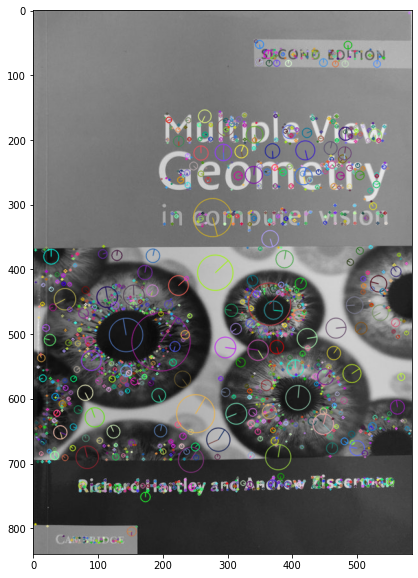

In [14]:
# cv2.drawKeypoints(image, keypoints, outImage, color, flags)
# flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS: This flag ensures that the keypoints are not just drawn as dots.
# Instead, they are drawn as circles where the size of the circle corresponds to the scale of the keypoint,
# and a line inside the circle indicates its orientation.
kp_img = cv2.drawKeypoints(gray, kp, img, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize = (10,10))
plt.imshow(kp_img)

Let's load the image `More_books.jpg` and convert it to grayscale.

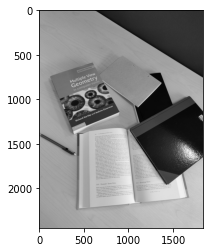

In [15]:
img2 = cv2.imread(path + "More_books.jpg")
b,g,r = cv2.split(img2) # Changing the order from bgr to rgb so that matplotlib can show it
img2 = cv2.merge([r,g,b])

gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
plt.imshow(gray2, cmap = 'gray')

We use the same SIFT method again to find the keypoints and descriptors of this image.

In [16]:
kp2, des2 = sift.detectAndCompute(gray2, None)

Now that we have the descriptors of both images, let's see if we can match them and find the book from the first image in the second image.
For this example we use the **Brute Force Matcher** ([`cv2.BFMatcher`](https://docs.opencv.org/4.7.0/d3/da1/classcv_1_1BFMatcher.html)). We use the function `cv2.match` to find the matches.

In [17]:
# Create a Brute-Force Matcher object.
# It works by taking the descriptor of one feature in the first set and matching it with all other features in the second set 
# using some distance calculation (default is Euclidean distance, L2-norm, for SIFT).
# It returns the closest match.
bf = cv2.BFMatcher()

# match(queryDescriptors, trainDescriptors)
# queryDescriptors: The descriptors from the first image (the book we want to find).
# trainDescriptors: The descriptors from the second image (the pile of books).
# Returns a list of DMatch objects. Each DMatch object holds the index of the matching keypoints and the distance between them.
matches = bf.match(des, des2)

We use the function [`cv2.drawMatches`](https://docs.opencv.org/4.7.0/d4/d5d/group__features2d__draw.html#gad8f463ccaf0dc6f61083abd8717c261a) to display the result. We'd like to display the best of the matches. The matching is made using a distance measurement between the descriptor: The smaller the distance, the better the match. So we sort the `matches` array using the distance term and then we plot only the first 100 matches.

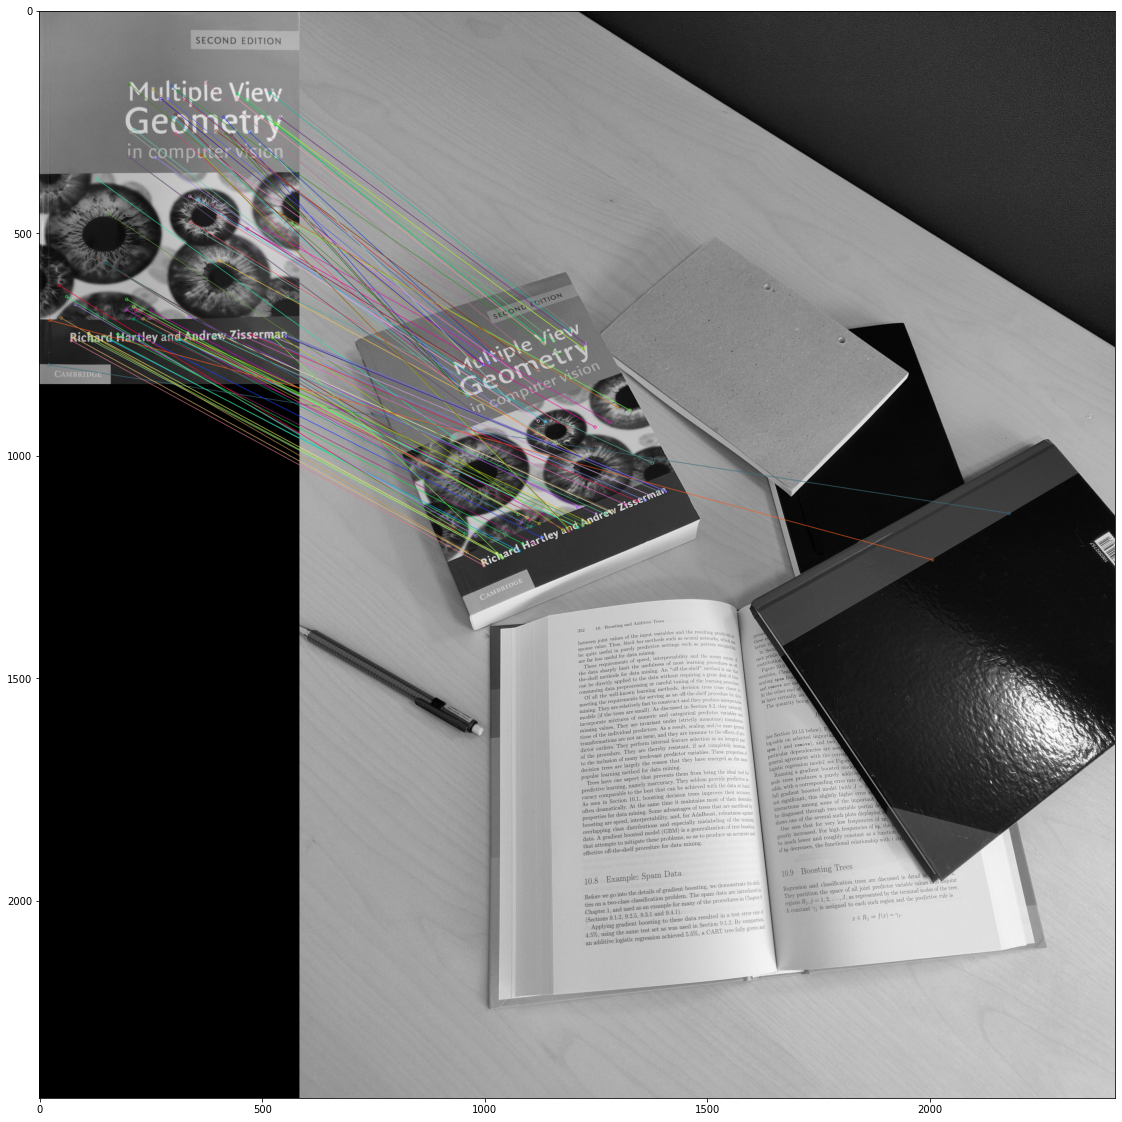

In [18]:
# Sort the matches based on their distance attribute.
# The 'distance' represents how similar the two descriptors are. Lower distance = Better match.
matches = sorted(matches, key = lambda x:x.distance)



# cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches1to2, outImg, flags)
# We only pass matches[:100] to visualize the top 100 best matches (lowest distance).
# flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS: This ensures that keypoints that did NOT find a match are not drawn, reducing clutter.
img3 = cv2.drawMatches(gray,kp,gray2,kp2,matches[:100],None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize = (20,20))
plt.imshow(img3)

We see that most of the matches are correct, but with some outliers.

# Exercise 3
Using the same two images, try to use Oriented BRIEF ([ORB](https://docs.opencv.org/4.7.0/db/d95/classcv_1_1ORB.html)) instead of SIFT to find the keypoints and the descriptors. Does one of these methods give a better result than the other? Try plotting more than just the best 100 matches and see if there is a difference between the two methods.

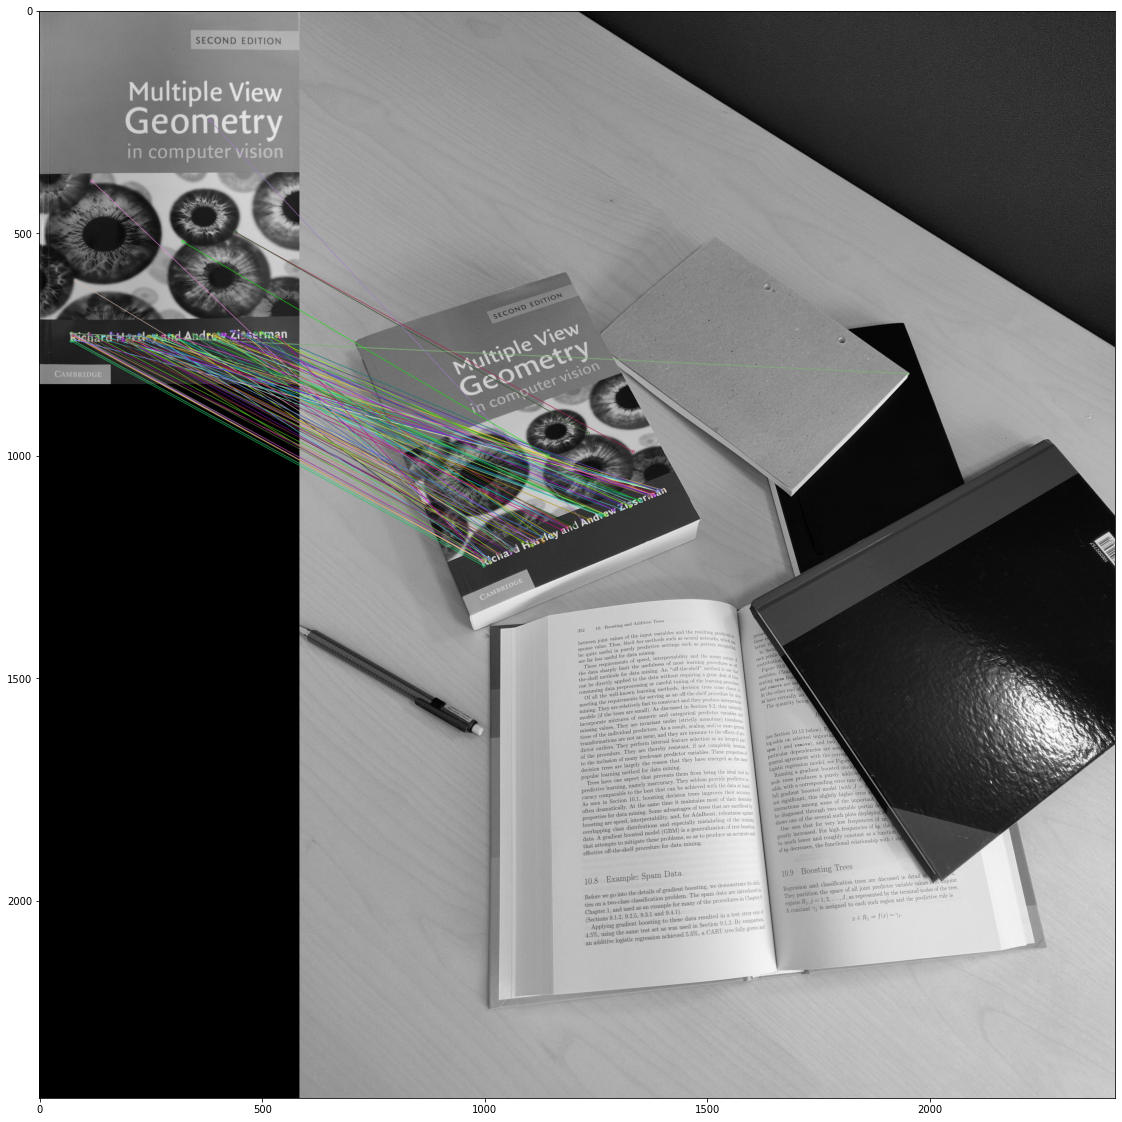

In [19]:
# Create the ORB detector.
# ORB (Oriented FAST and Rotated BRIEF) is a fast binary descriptor.
# Unlike SIFT (which is float-based), ORB is often faster and efficient but creates binary descriptors.
orb = cv2.ORB_create()

# Compute keypoints and descriptors for both images using ORB
kp, des = orb.detectAndCompute(gray, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

# Initialize Brute Force Matcher.
# Note: For binary descriptors like ORB, Hamming distance (cv2.NORM_HAMMING) is usually preferred over L2 Norm,
# but the default BFMatcher uses L2 unless specified. It will still work, but Hamming is theoretically more correct for ORB.
bf = cv2.BFMatcher()
matches = bf.match(des, des2)

# Sort matches by distance (asc) to get the best matches first
matches = sorted(matches, key = lambda x:x.distance)

# Visualize the matches
img3 = cv2.drawMatches(gray, kp, gray2, kp2, matches[:100], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize = (20, 20))
plt.imshow(img3)